# Distributed KV Cache System
## 분산 시스템 프로젝트 | 202126855 김형우

**비교 대상**

| | 방식 | 역할 |
|---|---|---|
| Case 1 | Single GPU (VRAM only) | 상한선 |
| Case 2 | CPU Offload (PCIe 왕복) | Baseline |
| Case 3 | Network Cache (1GbE, 소켓 에뮬레이션) | 제안 방식 |

> 실험 환경: Google Colab T4 단일 노드, time.sleep()으로 네트워크 지연 에뮬레이션

## 0. 초기 설정

In [7]:
!pip install -U bitsandbytes>=0.46.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
성공적으로 토큰을 불러왔습니다.


In [ ]:
import os

file_path = '/content/drive/MyDrive/colab_ModelLoad.txt'

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        hf_token = f.read().strip()
    print("성공적으로 토큰을 불러왔습니다.")
else:
    assert(f"오류: '{file_path}' 경로에 파일이 없습니다. 경로를 다시 확인해주세요.")

from huggingface_hub import login
login(token=hf_token)

### 1. 실험 설정

In [1]:
import os, io, json, time, pickle, socket, struct, threading
import warnings, uuid
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch

warnings.filterwarnings('ignore')
assert torch.cuda.is_available(), 'Runtime > 하드웨어 가속기 > GPU 설정 필요'

DEVICE     = 'cuda'
VRAM_TOTAL = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {VRAM_TOTAL:.1f} GB')

MODEL_NAME     = 'Qwen/Qwen2.5-7B-Instruct'
USE_4BIT       = False
MAX_NEW_TOKENS = 100
WORKER_HOST    = '127.0.0.1'
WORKER_PORT    = 50051

NETWORK_SCENARIOS = {
    '1GbE' : {'bw_gbps': 1.0,  'rtt_ms': 1.0},
    '10GbE': {'bw_gbps': 10.0, 'rtt_ms': 0.5},
    '25GbE': {'bw_gbps': 25.0, 'rtt_ms': 0.3},
}
ACTIVE_SCENARIO = '1GbE'

TEST_PROMPT = (
    'Describe in detail how transformer attention mechanisms work, '
    'including scaled dot-product attention and multi-head attention. '
    'Explain how key-value caching speeds up autoregressive generation:'
)
print('설정 완료')

GPU  : Tesla T4
VRAM : 15.6 GB
설정 완료


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if USE_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_cfg,
        device_map='auto', trust_remote_code=True)
else:
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.float16,
        device_map='cuda', trust_remote_code=True)

model.eval()
vram_used = torch.cuda.memory_allocated() / 1e9
print(f'모델 로드 완료')
print(f'VRAM 사용: {vram_used:.2f} GB  |  잔여: {VRAM_TOTAL-vram_used:.2f} GB')

COMMON = dict(model=model, tokenizer=tokenizer,
              device=DEVICE, max_new_tokens=MAX_NEW_TOKENS)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

모델 로드 완료
VRAM 사용: 15.23 GB  |  잔여: 0.40 GB


In [5]:
# 짧은 프롬프트로 테스트
test = tokenizer("Hello", return_tensors="pt").to("cuda")
with torch.no_grad():
    out = model.generate(**test, max_new_tokens=10)
print(tokenizer.decode(out[0]))
print(f"현재 VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Hello, I have a question about the following problem:
현재 VRAM: 15.24 GB


### 2. 수학적 모델

In [6]:
# Qwen2.5 7B 파라미터
# 모델 config에서 실제 파라미터 업데이트 (하드코딩 값 덮어쓰기)
N_LAYERS    = model.config.num_hidden_layers
N_KV_HEADS  = model.config.num_key_value_heads
D_HEAD      = model.config.hidden_size // model.config.num_attention_heads
DTYPE_BYTES = 2  # float16 — 4-bit 양자화해도 KV 캐시는 float16 유지

def kv_size(seq_len: int) -> float:
    # Size(KV) = 2 x N_layers x N_kv_heads x d_head x L_seq x sizeof(dtype)
    return 2 * N_LAYERS * N_KV_HEADS * D_HEAD * seq_len * DTYPE_BYTES

def t_offload(seq_len: int, bw_pcie_gbps: float = 8.0,
              t_cpu_ms: float = 0.3) -> float:
    # T_offload = Size(KV) / BW_PCIe_eff + T_cpu_access  [seconds]
    return kv_size(seq_len) / (bw_pcie_gbps * 1e9 / 8) + t_cpu_ms / 1e3

def t_dist(seq_len: int, bw_gbps: float, rtt_ms: float) -> float:
    # T_dist = Size(KV) / BW_net + RTT_net  [seconds]
    return kv_size(seq_len) / (bw_gbps * 1e9 / 8) + rtt_ms / 1e3

print(f"N_LAYERS   : {N_LAYERS}")
print(f"N_KV_HEADS : {N_KV_HEADS}  ← GQA (Query heads: {model.config.num_attention_heads})")
print(f"D_HEAD     : {D_HEAD}")
print(f"KV/token   : {kv_size(1)/1024:.2f} KB")
print(f"KV @ 2000  : {kv_size(2000)/1e6:.2f} MB")

# 임계점 분석 테이블
print(f"{'L_seq':>7}  {'KV(MB)':>8}  {'T_off(ms)':>10}  "
      + '  '.join(f'{n:>18}' for n in NETWORK_SCENARIOS))
print('-' * 80)
for seq in [512, 1024, 2048, 4096, 8192, 32768, 131072]:
    t_off = t_offload(seq) * 1e3
    row = f'{seq:>7}  {kv_size(seq)/1e6:>8.1f}  {t_off:>10.1f}  '
    for sc_name, sc in NETWORK_SCENARIOS.items():
        t_d = t_dist(seq, sc['bw_gbps'], sc['rtt_ms']) * 1e3
        flag = 'OK' if t_d < t_off else '--'
        row += f'  {flag} {t_d:>9.1f}ms'
    print(row)
print('\nOK=분산 우위  --=CPU Offload 우위  (PCIe 실효 8 Gbps 가정)')

N_LAYERS   : 28
N_KV_HEADS : 4  ← GQA (Query heads: 28)
D_HEAD     : 128
KV/token   : 56.00 KB
KV @ 2000  : 114.69 MB
  L_seq    KV(MB)   T_off(ms)                1GbE               10GbE               25GbE
--------------------------------------------------------------------------------
    512      29.4        29.7    --     235.9ms  OK      24.0ms  OK       9.7ms
   1024      58.7        59.0    --     470.8ms  OK      47.5ms  OK      19.1ms
   2048     117.4       117.7    --     940.5ms  OK      94.5ms  OK      37.9ms
   4096     234.9       235.2    --    1880.0ms  OK     188.4ms  OK      75.5ms
   8192     469.8       470.1    --    3759.1ms  OK     376.3ms  OK     150.6ms
  32768    1879.0      1879.3    --   15033.4ms  OK    1503.7ms  OK     601.6ms
 131072    7516.2      7516.5    --   60130.5ms  OK    6013.5ms  OK    2405.5ms

OK=분산 우위  --=CPU Offload 우위  (PCIe 실효 8 Gbps 가정)


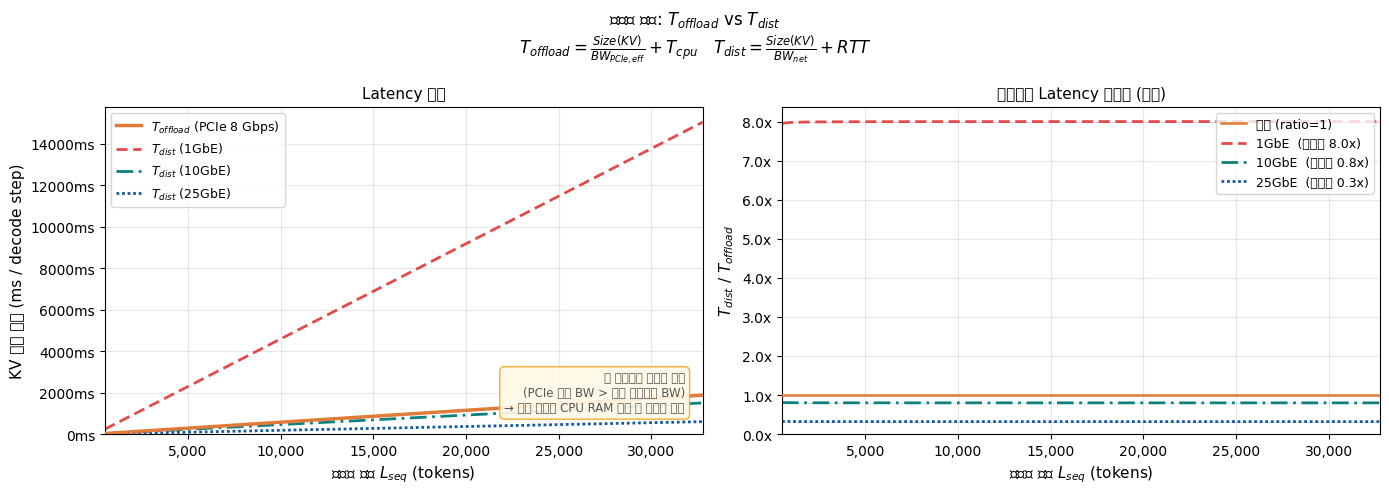

In [7]:
def plot_theoretical():
    seq_range = np.arange(512, 32769, 256)
    t_off = np.array([t_offload(s) * 1e3 for s in seq_range])
    t_nets = {
        name: np.array([t_dist(s, sc['bw_gbps'], sc['rtt_ms']) * 1e3
                        for s in seq_range])
        for name, sc in NETWORK_SCENARIOS.items()
    }

    def find_crossover(t_off, t_net, x):
        diff = t_net - t_off
        for i in range(len(diff) - 1):
            if diff[i] >= 0 and diff[i+1] < 0:
                r = -diff[i] / (diff[i+1] - diff[i])
                return float(x[i] + r * (x[i+1] - x[i]))
        return None

    crossovers = {name: find_crossover(t_off, t_nets[name], seq_range)
                  for name in NETWORK_SCENARIOS}

    NET_COLOR  = {'1GbE':'#E24B4A','10GbE':'#0E8080','25GbE':'#1458A0'}
    NET_LSTYLE = {'1GbE':(4,2),'10GbE':(6,2,1,2),'25GbE':(1,1)}
    OFF_COLOR  = '#E07B39'

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        r'수학적 모델: $T_{offload}$ vs $T_{dist}$'
        '\n'
        r'$T_{offload}=\frac{Size(KV)}{BW_{PCIe,eff}}+T_{cpu}$   '
        r'$T_{dist}=\frac{Size(KV)}{BW_{net}}+RTT$',
        fontsize=12)

    ax = axes[0]
    ax.plot(seq_range, t_off, color=OFF_COLOR, lw=2.5, zorder=3,
            label=f'$T_{{offload}}$ (PCIe 8 Gbps)')
    for name, t_net in t_nets.items():
        ax.plot(seq_range, t_net, color=NET_COLOR[name], lw=2,
                dashes=NET_LSTYLE[name], zorder=2, label=f'$T_{{dist}}$ ({name})')
        xpt = crossovers[name]
        if xpt is not None and seq_range[0] <= xpt <= seq_range[-1]:
            y_xpt = np.interp(xpt, seq_range, t_off)
            ax.axvline(xpt, color=NET_COLOR[name], lw=1.2,
                       linestyle='--', alpha=0.7, zorder=1)
            ax.scatter([xpt], [y_xpt], color=NET_COLOR[name],
                       s=70, zorder=5, ec='white', lw=0.8)
            ax.annotate(
                f'$L^*$={int(xpt):,}',
                xy=(xpt, y_xpt), xytext=(xpt+800, y_xpt*1.12),
                fontsize=8.5, color=NET_COLOR[name],
                arrowprops=dict(arrowstyle='-', color=NET_COLOR[name],
                                lw=0.8, shrinkA=0, shrinkB=0))
    if all(v is None for v in crossovers.values()):
        ax.text(0.97, 0.06,
                '이 범위에서 교차점 없음\n'
                '(PCIe 실효 BW > 모든 네트워크 BW)\n'
                '→ 분산 캐시는 CPU RAM 소진 시 유일한 대안',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.4',
                          fc='#FFF9E6', ec='#F5A623', alpha=0.92))
    ax.set_xlabel('시퀀스 길이 $L_{seq}$ (tokens)', fontsize=11)
    ax.set_ylabel('KV 전송 지연 (ms / decode step)', fontsize=11)
    ax.set_title('Latency 비교', fontsize=11)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y:.0f}ms'))
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(seq_range[0], seq_range[-1])
    ax.set_ylim(bottom=0)

    ax2 = axes[1]
    ax2.axhline(1.0, color=OFF_COLOR, lw=1.8, label='기준 (ratio=1)', zorder=3)
    for name, t_net in t_nets.items():
        ratio = t_net / t_off
        ax2.plot(seq_range, ratio, color=NET_COLOR[name], lw=2,
                 dashes=NET_LSTYLE[name], zorder=2,
                 label=f'{name}  (점근값 {ratio[-1]:.1f}x)')
        ax2.axhline(ratio[-1], color=NET_COLOR[name],
                    lw=0.7, linestyle=':', alpha=0.45)
    ax2.set_xlabel('시퀀스 길이 $L_{seq}$ (tokens)', fontsize=11)
    ax2.set_ylabel('$T_{dist}$ / $T_{offload}$', fontsize=11)
    ax2.set_title('네트워크 Latency 패널티 (배율)', fontsize=11)
    ax2.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, _: f'{y:.1f}x'))
    ax2.legend(fontsize=9, loc='upper right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(seq_range[0], seq_range[-1])
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig('math_model.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_theoretical()

## 3. KV 캐시 서버 / 클라이언트

In [8]:
def _send(sock, data: bytes):
    sock.sendall(struct.pack('>Q', len(data)) + data)

def _recv_exact(sock, n):
    buf = bytearray()
    while len(buf) < n:
        chunk = sock.recv(n - len(buf))
        if not chunk: raise ConnectionError('연결 끊김')
        buf.extend(chunk)
    return bytes(buf)

def _recv(sock):
    return _recv_exact(sock, struct.unpack('>Q', _recv_exact(sock, 8))[0])

def _kv_to_bytes(kv):
    buf = io.BytesIO()
    torch.save([(k.cpu(), v.cpu()) for k, v in kv], buf)
    return buf.getvalue()

def _bytes_to_kv(data):
    return torch.load(io.BytesIO(data), map_location='cpu', weights_only=False)


class KVCacheServer:
    def __init__(self, host='127.0.0.1', port=50051, bw_gbps=1.0, rtt_ms=1.0):
        self.host, self.port = host, port
        self.bw_gbps, self.rtt_ms = bw_gbps, rtt_ms
        self._store = {}
        self._lock  = threading.Lock()
        self._stats = {'put':0,'get':0,'bytes_in':0,'bytes_out':0}
        self._running = False

    def _delay(self, n):
        # BW 에뮬레이션: data_bytes / (bw_gbps x 1e9/8) + rtt_ms/2
        time.sleep(n / (self.bw_gbps * 1e9 / 8) + self.rtt_ms / 2e3)

    def _handle(self, conn, addr):
        try:
            while True:
                req = pickle.loads(_recv(conn))
                cmd, key = req['cmd'], req['key']
                if cmd == 'PUT':
                    pl = req['payload']; self._delay(len(pl))
                    with self._lock:
                        self._store[key] = pl
                        self._stats['put'] += 1
                        self._stats['bytes_in'] += len(pl)
                    _send(conn, pickle.dumps({'ok': True}))
                elif cmd == 'GET':
                    with self._lock:
                        pl = self._store.get(key)
                        if pl:
                            self._stats['get'] += 1
                            self._stats['bytes_out'] += len(pl)
                    if pl is None:
                        _send(conn, pickle.dumps({'ok': False}))
                    else:
                        self._delay(len(pl))
                        _send(conn, pickle.dumps({'ok': True, 'payload': pl}))
                elif cmd == 'DEL':
                    with self._lock: self._store.pop(key, None)
                    _send(conn, pickle.dumps({'ok': True}))
                elif cmd == 'PING':
                    _send(conn, pickle.dumps({'ok': True}))
        except: pass
        finally: conn.close()

    def start(self):
        self._sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self._sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
        self._sock.bind((self.host, self.port))
        self._sock.listen(16); self._sock.settimeout(1.0)
        self._running = True
        def _loop():
            while self._running:
                try:
                    conn, addr = self._sock.accept()
                    threading.Thread(target=self._handle,
                                     args=(conn, addr), daemon=True).start()
                except socket.timeout: continue
                except OSError: break
        self._t = threading.Thread(target=_loop, daemon=True)
        self._t.start()

    def stop(self):
        self._running = False
        try: self._sock.close()
        except: pass
        self._t.join(timeout=2)

    def get_stats(self):
        with self._lock: return dict(self._stats)


class KVCacheClient:
    def __init__(self, host='127.0.0.1', port=50051):
        self.host, self.port = host, port; self._sock = None

    def connect(self):
        self._sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self._sock.connect((self.host, self.port))

    def disconnect(self):
        if self._sock:
            try: self._sock.close()
            except: pass
            self._sock = None

    def _req(self, msg):
        _send(self._sock, pickle.dumps(msg))
        return pickle.loads(_recv(self._sock))

    def put(self, key, kv):
        r = self._req({'cmd':'PUT','key':key,'payload':_kv_to_bytes(kv)})
        if not r['ok']: raise RuntimeError('PUT failed')

    def get(self, key):
        r = self._req({'cmd':'GET','key':key})
        if not r['ok']: raise RuntimeError('GET failed')
        return _bytes_to_kv(r['payload'])

    def delete(self, key): self._req({'cmd':'DEL','key':key})

print('KV 서버/클라이언트 준비 완료')

KV 서버/클라이언트 준비 완료


## 4. 공통 자료구조 & 베이스 엔진

In [19]:
from transformers import DynamicCache

@dataclass
class StepTiming:
    step_idx:      int
    total_s:       float
    model_fwd_s:   float
    kv_transfer_s: float
    kv_size_bytes: int

@dataclass
class BenchmarkResult:
    engine_name:      str
    prompt_tokens:    int
    ttft_s:           float
    tps:              float
    tokens_generated: int
    total_s:          float
    step_timings:     List[StepTiming] = field(default_factory=list)
    error:            Optional[str]    = None

    @property
    def avg_kv_ms(self):
        if not self.step_timings: return 0.0
        return sum(s.kv_transfer_s for s in self.step_timings)/len(self.step_timings)*1e3

    @property
    def avg_fwd_ms(self):
        if not self.step_timings: return 0.0
        return sum(s.model_fwd_s for s in self.step_timings)/len(self.step_timings)*1e3

    @property
    def kv_ratio(self):
        a = sum(s.kv_transfer_s for s in self.step_timings)
        b = sum(s.total_s for s in self.step_timings)
        return a/b if b > 0 else 0.0


def kv_to_list(pkv) -> list:
    if pkv is None:
        return []
    try:
        from transformers import DynamicCache
        if isinstance(pkv, DynamicCache):
            return [(pkv.key_cache[i], pkv.value_cache[i])
                    for i in range(len(pkv.key_cache))]
    except ImportError:
        pass
    # legacy tuple-of-tuples
    if isinstance(pkv[0], (tuple, list)):
        return [(k, v) for k, v in pkv]
    return [(pkv[i], pkv[i+1]) for i in range(0, len(pkv), 2)]

def list_to_kv(kv_list: list, device: str = 'cuda'):
    try:
        c = DynamicCache()
        c.key_cache   = [k.to(device) for k, v in kv_list]
        c.value_cache = [v.to(device) for k, v in kv_list]
        return c
    except ImportError:
        return tuple((k.to(device), v.to(device)) for k, v in kv_list)

def kv_bytes_size(kv_list: list) -> int:
    return sum(k.element_size()*k.numel() + v.element_size()*v.numel()
               for k, v in kv_list)


class BaseEngine(ABC):
    ENGINE_NAME = 'base'

    def __init__(self, model, tokenizer, device='cuda', max_new_tokens=100):
        self.model = model; self.tokenizer = tokenizer
        self.device = device; self.max_new_tokens = max_new_tokens

    @abstractmethod
    def _prefill(self, input_ids) -> Tuple[int, any]: ...

    @abstractmethod
    def _decode_step(self, token_id, kv_state, step_idx) -> Tuple[int, any, StepTiming]: ...

    def _cleanup(self): pass

    def generate(self, prompt: str) -> BenchmarkResult:
        input_ids = self.tokenizer(prompt, return_tensors='pt')['input_ids'].to(self.device)
        n_prompt  = input_ids.shape[1]
        t0 = time.perf_counter()
        try:
            first_id, kv_state = self._prefill(input_ids)
        except Exception as e:
            return BenchmarkResult(self.ENGINE_NAME, n_prompt, 0,0,0,0, error=str(e))
        ttft = time.perf_counter() - t0

        generated, timings = [first_id], []
        eos = self.tokenizer.eos_token_id
        t_dec = time.perf_counter()
        for step in range(self.max_new_tokens - 1):
            try:
                nxt, kv_state, timing = self._decode_step(generated[-1], kv_state, step)
            except Exception as e:
                print(f'  decode error @ step {step}: {e}'); break
            timings.append(timing); generated.append(nxt)
            if nxt == eos: break
        t_end = time.perf_counter()
        self._cleanup()
        dt = t_end - t_dec
        return BenchmarkResult(
            engine_name=self.ENGINE_NAME, prompt_tokens=n_prompt,
            ttft_s=ttft, tps=(len(generated)-1)/dt if dt>0 else 0,
            tokens_generated=len(generated), total_s=t_end-t0,
            step_timings=timings)

print('베이스 엔진 준비 완료')

베이스 엔진 준비 완료


## 5. 추론 엔진 구현 (3종)

In [20]:
# ============================================================
# Case 1: Single GPU (VRAM Only)
# KV 캐시를 VRAM에만 유지, 이동 없음 → kv_transfer_s = 0
# ============================================================

class SingleGPUEngine(BaseEngine):
    ENGINE_NAME = 'Case1_SingleGPU'

    def _prefill(self, input_ids):
        with torch.no_grad():
            out = self.model(input_ids=input_ids, use_cache=True, return_dict=True)
        first_id = int(out.logits[:, -1, :].argmax(-1).item())
        return first_id, kv_to_list(out.past_key_values)

    def _decode_step(self, token_id, kv_list, step_idx):
        ids = torch.tensor([[token_id]], device=self.device)
        sz  = kv_bytes_size(kv_list)
        t0  = time.perf_counter()
        with torch.no_grad():
            out = self.model(
                input_ids=ids,
                past_key_values=list_to_kv(kv_list, self.device),
                use_cache=True, return_dict=True)
        torch.cuda.synchronize()
        t1 = time.perf_counter()
        return (
            int(out.logits[:, -1, :].argmax(-1).item()),
            kv_to_list(out.past_key_values),
            StepTiming(step_idx, t1-t0, t1-t0, 0.0, sz))


# ============================================================
# Case 2: CPU Offload
# 매 스텝 KV를 CPU RAM <-> GPU PCIe 왕복
# kv_transfer_s = PCIe 업로드 + 다운로드 시간
# ============================================================

class CPUOffloadEngine(BaseEngine):
    ENGINE_NAME = 'Case2_CPUOffload'

    def _prefill(self, input_ids):
        with torch.no_grad():
            out = self.model(input_ids=input_ids, use_cache=True, return_dict=True)
        first_id = int(out.logits[:, -1, :].argmax(-1).item())
        kv_cpu = [(k.cpu(), v.cpu()) for k, v in kv_to_list(out.past_key_values)]
        torch.cuda.empty_cache()
        return first_id, kv_cpu

    def _decode_step(self, token_id, kv_cpu, step_idx):
        ids = torch.tensor([[token_id]], device=self.device)
        sz  = kv_bytes_size(kv_cpu)
        t_start = time.perf_counter()

        t_up0 = time.perf_counter()
        kv_gpu = [(k.to(self.device), v.to(self.device)) for k, v in kv_cpu]
        t_up1 = time.perf_counter()

        t_f0 = time.perf_counter()
        with torch.no_grad():
            out = self.model(
                input_ids=ids,
                past_key_values=list_to_kv(kv_gpu, self.device),
                use_cache=True, return_dict=True)
        torch.cuda.synchronize()
        t_f1 = time.perf_counter()

        t_dn0 = time.perf_counter()
        new_kv = [(k.cpu(), v.cpu()) for k, v in kv_to_list(out.past_key_values)]
        torch.cuda.empty_cache()
        t_dn1 = time.perf_counter()

        t_end = time.perf_counter()
        return (
            int(out.logits[:, -1, :].argmax(-1).item()),
            new_kv,
            StepTiming(step_idx, t_end-t_start, t_f1-t_f0,
                       (t_up1-t_up0)+(t_dn1-t_dn0), sz))


# ============================================================
# Case 3: Network Cache
# KV를 소켓 서버(워커 노드 시뮬레이션)에 저장
# kv_transfer_s = 네트워크 PUT + GET 왕복 시간 (BW/RTT 에뮬레이션 포함)
# ============================================================

class NetworkCacheEngine(BaseEngine):
    ENGINE_NAME = 'Case3_NetworkCache'

    def __init__(self, *args, client: KVCacheClient, **kwargs):
        super().__init__(*args, **kwargs)
        self._client = client
        self._sid    = f'kv_{uuid.uuid4().hex[:8]}'

    def _prefill(self, input_ids):
        with torch.no_grad():
            out = self.model(input_ids=input_ids, use_cache=True, return_dict=True)
        first_id = int(out.logits[:, -1, :].argmax(-1).item())
        self._client.put(self._sid, kv_to_list(out.past_key_values))
        torch.cuda.empty_cache()
        return first_id, self._sid

    def _decode_step(self, token_id, sid, step_idx):
        ids = torch.tensor([[token_id]], device=self.device)
        t_start = time.perf_counter()

        t_rx0  = time.perf_counter()
        kv_cpu = self._client.get(sid)
        sz     = kv_bytes_size(kv_cpu)
        kv_gpu = [(k.to(self.device), v.to(self.device)) for k, v in kv_cpu]
        t_rx1  = time.perf_counter()

        t_f0 = time.perf_counter()
        with torch.no_grad():
            out = self.model(
                input_ids=ids,
                past_key_values=list_to_kv(kv_gpu, self.device),
                use_cache=True, return_dict=True)
        torch.cuda.synchronize()
        t_f1 = time.perf_counter()

        t_tx0 = time.perf_counter()
        self._client.put(sid, kv_to_list(out.past_key_values))
        torch.cuda.empty_cache()
        t_tx1 = time.perf_counter()

        t_end = time.perf_counter()
        return (
            int(out.logits[:, -1, :].argmax(-1).item()),
            sid,
            StepTiming(step_idx, t_end-t_start, t_f1-t_f0,
                       (t_rx1-t_rx0)+(t_tx1-t_tx0), sz))

    def _cleanup(self):
        try: self._client.delete(self._sid)
        except: pass

print('엔진 3종 준비 완료: SingleGPU / CPUOffload / NetworkCache')

엔진 3종 준비 완료: SingleGPU / CPUOffload / NetworkCache


## 7. 실험 실행

셀을 순서대로 실행. 각 셀은 독립적으로 재실행 가능.

In [21]:
RESULTS = {}

# ── Case 1: Single GPU ─────────────────────────────────────────────────
print('=' * 50)
print('Case 1: Single GPU (VRAM Only)')
print('=' * 50)

engine1 = SingleGPUEngine(**COMMON)
r1 = engine1.generate(TEST_PROMPT)
RESULTS['case1'] = r1
torch.cuda.empty_cache()

if r1.error:
    print(f'오류: {r1.error}')
else:
    print(f'  TTFT            : {r1.ttft_s*1e3:.1f} ms')
    print(f'  TPS             : {r1.tps:.2f} tokens/sec')
    print(f'  생성 토큰        : {r1.tokens_generated}')
    print(f'  avg KV 전송     : {r1.avg_kv_ms:.1f} ms/step  (이동 없음)')
    print(f'  avg Forward     : {r1.avg_fwd_ms:.1f} ms/step')

Case 1: Single GPU (VRAM Only)
오류: 'DynamicCache' object has no attribute 'key_cache'


In [12]:
# ── Case 2: CPU Offload ────────────────────────────────────────────────
print('=' * 50)
print('Case 2: CPU Offload (PCIe 왕복)')
print('=' * 50)

engine2 = CPUOffloadEngine(**COMMON)
r2 = engine2.generate(TEST_PROMPT)
RESULTS['case2'] = r2
torch.cuda.empty_cache()

if r2.error:
    print(f'오류: {r2.error}')
else:
    print(f'  TTFT            : {r2.ttft_s*1e3:.1f} ms')
    print(f'  TPS             : {r2.tps:.2f} tokens/sec')
    print(f'  생성 토큰        : {r2.tokens_generated}')
    print(f'  avg KV 전송     : {r2.avg_kv_ms:.1f} ms/step  (PCIe 왕복)')
    print(f'  avg Forward     : {r2.avg_fwd_ms:.1f} ms/step')
    print(f'  KV 전송 비율     : {r2.kv_ratio*100:.1f} %')

Case 2: CPU Offload (PCIe 왕복)
오류: too many values to unpack (expected 2)


In [ ]:
# ── Case 3: Network Cache (1GbE) ───────────────────────────────────────
sc = NETWORK_SCENARIOS[ACTIVE_SCENARIO]
print('=' * 50)
print(f'Case 3: Network Cache ({ACTIVE_SCENARIO})')
print(f'  BW={sc["bw_gbps"]} Gbps  RTT={sc["rtt_ms"]} ms')
print('=' * 50)

server = KVCacheServer(WORKER_HOST, WORKER_PORT, sc['bw_gbps'], sc['rtt_ms'])
server.start()
time.sleep(0.3)

client = KVCacheClient(WORKER_HOST, WORKER_PORT)
client.connect()

engine3 = NetworkCacheEngine(**COMMON, client=client)
r3 = engine3.generate(TEST_PROMPT)
RESULTS['case3'] = r3

srv_stats = server.get_stats()
client.disconnect()
server.stop()
torch.cuda.empty_cache()

if r3.error:
    print(f'오류: {r3.error}')
else:
    print(f'  TTFT            : {r3.ttft_s*1e3:.1f} ms')
    print(f'  TPS             : {r3.tps:.2f} tokens/sec')
    print(f'  생성 토큰        : {r3.tokens_generated}')
    print(f'  avg KV 전송     : {r3.avg_kv_ms:.1f} ms/step  (네트워크 왕복)')
    print(f'  avg Forward     : {r3.avg_fwd_ms:.1f} ms/step')
    print(f'  KV 전송 비율     : {r3.kv_ratio*100:.1f} %')
    print(f'  서버 PUT/GET    : {srv_stats["put"]}/{srv_stats["get"]}')
    print(f'  총 전송량        : {srv_stats["bytes_in"]/1e6:.1f} MB in'
          f' / {srv_stats["bytes_out"]/1e6:.1f} MB out')

## 8. 결과 시각화

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f'분산 KV 캐시 벤치마크  |  Qwen2.5 7B (4-bit) · T4 · {ACTIVE_SCENARIO}',
    fontsize=13, fontweight='bold')

KEYS   = ['case1', 'case2', 'case3']
LABELS = ['Single GPU', 'CPU Offload', f'Network Cache\n({ACTIVE_SCENARIO})']
COLORS = ['#1458A0', '#0E8080', '#E07B39']
RL     = [RESULTS[k] for k in KEYS if k in RESULTS]
LB     = [LABELS[i] for i, k in enumerate(KEYS) if k in RESULTS]
CL     = [COLORS[i] for i, k in enumerate(KEYS) if k in RESULTS]

def bar_ax(ax, vals, title, ylabel, fmt='{:.1f}'):
    bars = ax.bar(LB, vals, color=CL, width=0.5, edgecolor='white', lw=0.8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.02,
                fmt.format(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals)*1.28)
    ax.tick_params(axis='x', labelsize=9); ax.grid(axis='y', alpha=0.3)

if RL:
    bar_ax(axes[0,0], [r.ttft_s*1e3 for r in RL], 'TTFT (Time To First Token)',
           'ms', '{:.0f}ms')
    bar_ax(axes[0,1], [r.tps for r in RL], 'TPS (Tokens Per Second)',
           'tokens/sec', '{:.2f}')
    bar_ax(axes[0,2], [r.kv_ratio*100 for r in RL], 'KV 전송 비율 (decode 중)',
           '%', '{:.1f}%')

ax = axes[1,0]
for r, c, lb in zip(RL, CL, LB):
    if r.step_timings:
        ax.plot([s.kv_transfer_s*1e3 for s in r.step_timings],
                color=c, label=lb.replace('\n',' '), linewidth=1.5)
ax.set_title('스텝별 KV 전송 시간', fontweight='bold')
ax.set_xlabel('Decode 스텝'); ax.set_ylabel('ms')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,1]
for r, c, lb in zip(RL, CL, LB):
    if r.step_timings:
        ax.plot([s.model_fwd_s*1e3 for s in r.step_timings],
                color=c, label=lb.replace('\n',' '), linewidth=1.5)
ax.set_title('스텝별 모델 Forward 시간', fontweight='bold')
ax.set_xlabel('Decode 스텝'); ax.set_ylabel('ms')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1,2]
for r, c, lb in zip(RL, CL, LB):
    if r.step_timings:
        total_ms = [s.total_s*1e3 for s in r.step_timings]
        kv_ms    = [s.kv_transfer_s*1e3 for s in r.step_timings]
        fwd_ms   = [s.model_fwd_s*1e3 for s in r.step_timings]
        steps    = list(range(len(total_ms)))
        ax.stackplot(steps, fwd_ms, kv_ms,
                     labels=['Forward', 'KV 전송'],
                     colors=[c, c], alpha=[0.8, 0.3])
        break
ax.set_title(f'스텝 분해 ({LB[-1].replace(chr(10)," ")})', fontweight='bold')
ax.set_xlabel('Decode 스텝'); ax.set_ylabel('ms')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('benchmark_result.png 저장')

## 9. 수학적 모델 vs 시뮬레이션 오차 분석

In [ ]:
if 'case2' in RESULTS and 'case3' in RESULTS and not RESULTS['case2'].error:
    r_cpu = RESULTS['case2']
    r_net = RESULTS['case3']
    sc    = NETWORK_SCENARIOS[ACTIVE_SCENARIO]

    avg_seq = r_cpu.prompt_tokens + MAX_NEW_TOKENS // 2

    pred_cpu_ms = t_offload(avg_seq) * 1e3
    pred_net_ms = t_dist(avg_seq, sc['bw_gbps'], sc['rtt_ms']) * 1e3
    meas_cpu_ms = r_cpu.avg_kv_ms
    meas_net_ms = r_net.avg_kv_ms if not r_net.error else float('nan')

    print('=' * 64)
    print(f'  수학적 모델 예측 vs 시뮬레이션 실측')
    print(f'  기준 seq_len  : {avg_seq} tokens')
    print(f'  KV 이론 크기  : {kv_size(avg_seq)/1e6:.2f} MB')
    print('=' * 64)
    print(f'  {"":28}  {"CPU Offload":>12}  {"Net Cache":>12}')
    print(f'  {"모델 예측 (ms/step)":28}  {pred_cpu_ms:>12.1f}  {pred_net_ms:>12.1f}')
    print(f'  {"시뮬레이션 실측 (ms/step)":28}  {meas_cpu_ms:>12.1f}  {meas_net_ms:>12.1f}')
    if pred_cpu_ms > 0 and pred_net_ms > 0 and meas_net_ms == meas_net_ms:
        err_cpu = abs(meas_cpu_ms - pred_cpu_ms)
        err_net = abs(meas_net_ms - pred_net_ms)
        print(f'  {"절대 오차 (ms)":28}  {err_cpu:>12.1f}  {err_net:>12.1f}')
        print(f'  {"상대 오차 (%)":28}  {err_cpu/pred_cpu_ms*100:>11.1f}%  '
              f'{err_net/pred_net_ms*100:>11.1f}%')
    print('=' * 64)
    print()
    print('  오차 원인 분석:')
    print('  CPU Offload : PCIe 실효 BW 가정 오차, pageable 메모리 복사 overhead')
    print('  Net Cache   : pickle 직렬화/역직렬화 overhead, OS 스케줄링 지연')
else:
    print('Case 2, 3 실험 완료 후 재실행하세요.')

## 10. 최종 요약 및 저장

In [ ]:
# 결과 요약 테이블
KEYS   = ['case1','case2','case3']
LABELS = ['Single GPU','CPU Offload','Network Cache']
print('=' * 68)
print(f'  최종 결과 요약  [{ACTIVE_SCENARIO}]')
print('=' * 68)
print(f'  {"엔진":18} {"TTFT(ms)":>10} {"TPS":>8} '
      f'{"KV전송(ms)":>12} {"KV비율(%)":>10} {"Forward(ms)":>12}')
print('-' * 68)
for k, lb in zip(KEYS, LABELS):
    if k not in RESULTS: continue
    r = RESULTS[k]
    if r.error:
        print(f'  {lb:18} ERROR: {r.error[:40]}')
    else:
        print(f'  {lb:18} {r.ttft_s*1e3:>10.0f} {r.tps:>8.2f} '
              f'{r.avg_kv_ms:>12.1f} {r.kv_ratio*100:>10.1f} {r.avg_fwd_ms:>12.1f}')
print('=' * 68)

# JSON 저장
def to_dict(r: BenchmarkResult) -> dict:
    return {
        'engine': r.engine_name, 'ttft_ms': round(r.ttft_s*1e3, 1),
        'tps': round(r.tps, 3), 'tokens': r.tokens_generated,
        'avg_kv_ms': round(r.avg_kv_ms, 2),
        'avg_fwd_ms': round(r.avg_fwd_ms, 2),
        'kv_ratio_pct': round(r.kv_ratio*100, 1),
        'step_timings': [{'step':s.step_idx,'total_ms':round(s.total_s*1e3,2),
                          'fwd_ms':round(s.model_fwd_s*1e3,2),
                          'kv_ms':round(s.kv_transfer_s*1e3,2),
                          'kv_bytes':s.kv_size_bytes}
                         for s in r.step_timings]
    }

output = {'scenario': ACTIVE_SCENARIO,
          'model': MODEL_NAME,
          'max_new_tokens': MAX_NEW_TOKENS,
          'results': {k: to_dict(v) for k, v in RESULTS.items()}}
with open('results.json','w') as f:
    json.dump(output, f, indent=2)
print('\nresults.json 저장 완료')
print('benchmark_result.png, math_model.png 저장 완료')